# 📌 Baseline 모델 설계 문서 (OHLCV 기반 단일스텝 예측)

https://m.blog.naver.com/snowstormaw/222837950137

## ✅ 목적
Apple 주식 5년치 일별 OHLCV 데이터를 활용해 20일간의 시계열로 다음날 종가(달러)를 직접 예측. 타겟 스케일링 없이 실제 가격을 맞추는 단일스텝 회귀 문제 정의.

## ✅ 데이터 처리
- yfinance API (Apple 5년치)
- X: [Open, High, Low, Close, Volume]의 20일 윈도우
- y: 다음날 종가 (스케일링 없이 달러 단위)
- 전처리: X만 StandardScaler 적용, y는 스케일링하지 않음

## ✅ 모델 아키텍처
- LSTM(48 units) + Dropout(0.4)
- Dense(64, relu) + Dropout(0.4)
- Dense(1)
- Loss: MAE
- Optimizer: Adam(0.01)

## ✅ 데이터 분할
- 학습/검증: 2021년까지
- 테스트: 2022년 전체
- 검증 데이터: 학습의 20% 랜덤 분할

## ✅ 성능 결과 (2022 Test set)
- MAE ≈ 3.2달러
- RMSE ≈ 4.0달러
- R² ≈ 0.90
- 평균 주가 130~180달러 구간에서 약 2~3% 수준 오차

## ✅ 인사이트
- OHLCV 기반 단일 시계열만으로도 준수한 성능
- 기술적 지표 없이 순수 시계열 정보만으로 baseline 확보
- 서비스 적용에 적합 (해석성 높음, 가격 단위 출력)

## ✅ 향후 계획
- RSI, MACD, OBV 등 기술적 지표 추가
- 윈도우 크기 조정 (10~60일)
- 다중스텝 예측(horizon>1)
- GRU, Transformer 등 모델 아키텍처 개선
- Feature Selection 및 변수 중요도 분석


In [13]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split

In [14]:
# ✅ 1. 데이터 수집
aapl = yf.download('AAPL', start='2017-01-01', end='2022-12-31')
aapl = aapl[['Open','High','Low','Close','Volume']].dropna()
aapl.reset_index(drop=True, inplace=True)

/tmp/ipykernel_59372/3812156965.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl = yf.download('AAPL', start='2017-01-01', end='2022-12-31')
[*********************100%***********************]  1 of 1 completed


In [15]:
# ✅ 2. 종가2 컬럼 추가 (타겟)
aapl['Close_Target'] = aapl['Close']

In [16]:
# ✅ 3. 스케일링 (X만, y는 그대로)
scaler = StandardScaler()
aapl.iloc[:, 0:5] = scaler.fit_transform(aapl.iloc[:, 0:5])

In [17]:
# ✅ 4. 윈도우 데이터 생성
윈사이즈 = 20
x_list, y_list = [], []
for i in range(len(aapl) - 윈사이즈):
    x_tmp = aapl.iloc[i:i+윈사이즈, 0:5]
    y_tmp = aapl.iloc[i+윈사이즈, 5]
    x_list.append(x_tmp)
    y_list.append(y_tmp)

x_arr = np.array(x_list)
y_arr = np.array(y_list)

print('X 데이터 형태:', x_arr.shape)
print('y 데이터 형태:', y_arr.shape)

X 데이터 형태: (1490, 20, 5)
y 데이터 형태: (1490,)


In [18]:
# ✅ 5. 시계열 분할
# 2022년 1월 기준 분할
split_date = '2022-01-03'
aapl_dates = yf.download('AAPL', start='2017-01-01', end='2022-12-31').index
aapl_dates = aapl_dates[윈사이즈:]
split_idx = np.where(aapl_dates >= np.datetime64(split_date))[0][0]

/tmp/ipykernel_59372/3743457646.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl_dates = yf.download('AAPL', start='2017-01-01', end='2022-12-31').index
[*********************100%***********************]  1 of 1 completed


In [19]:
print('2022년 분할 위치:', split_idx)

x_train_full = x_arr[:split_idx]
y_train_full = y_arr[:split_idx]
x_test = x_arr[split_idx:]
y_test = y_arr[split_idx:]

print('Train 전체:', x_train_full.shape, y_train_full.shape)
print('Test:', x_test.shape, y_test.shape)

2022년 분할 위치: 1239
Train 전체: (1239, 20, 5) (1239,)
Test: (251, 20, 5) (251,)


In [20]:
# ✅ 6. 검증 데이터 분리
x_tr, x_val, y_tr, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.2, shuffle=True, random_state=42
)

print('Train:', x_tr.shape)
print('Validation:', x_val.shape)

Train: (991, 20, 5)
Validation: (248, 20, 5)


In [22]:
# ✅ 7. 모델 설계
모델 = keras.Sequential()
모델.add(LSTM(48, activation='tanh', input_shape=(윈사이즈, 5)))
모델.add(Dropout(0.4))
모델.add(Dense(64, activation='relu'))
모델.add(Dropout(0.4))
모델.add(Dense(1))  # 회귀 → 종가 단일 출력

모델.compile(
    loss='mae',
    optimizer=keras.optimizers.Adam(0.01),
    metrics=['mae']
)

2025-06-30 14:28:13.097570: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-06-30 14:28:13.099727: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-06-30 14:28:13.102168: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [21]:
# ✅ 7. 모델 설계
모델 = keras.Sequential()
모델.add(LSTM(48, activation='tanh', input_shape=(윈사이즈, 5)))
모델.add(Dropout(0.4))
모델.add(Dense(64, activation='relu'))
모델.add(Dropout(0.4))
모델.add(Dense(1))  # 회귀 → 종가 단일 출력

모델.compile(
    loss='mae',
    optimizer=keras.optimizers.Adam(0.01),
    metrics=['mae']
)


2025-06-30 14:27:49.925353: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-06-30 14:27:49.927069: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-06-30 14:27:49.928470: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [23]:
# ✅ 8. 콜백
cbk = ModelCheckpoint('best_model.h5', save_weights_only=True,
                      monitor='val_mae', mode='auto', save_best_only=True)
es = EarlyStopping(patience=100, restore_best_weights=True)

In [24]:
# ✅ 9. 학습
히스토리 = 모델.fit(
    x_tr, y_tr,
    validation_data=(x_val, y_val),
    epochs=150,
    batch_size=32,
    callbacks=[cbk, es],
    verbose=2
)

Epoch 1/150


2025-06-30 14:28:30.476541: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-06-30 14:28:30.478765: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-06-30 14:28:30.480040: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

31/31 - 2s - loss: 51.8185 - mae: 51.8185 - val_loss: 32.2021 - val_mae: 32.2021 - 2s/epoch - 78ms/step
Epoch 2/150
31/31 - 0s - loss: 24.5666 - mae: 24.5666 - val_loss: 11.2176 - val_mae: 11.2176 - 400ms/epoch - 13ms/step
Epoch 3/150
31/31 - 0s - loss: 15.8210 - mae: 15.8210 - val_loss: 7.7298 - val_mae: 7.7298 - 393ms/epoch - 13ms/step
Epoch 4/150
31/31 - 0s - loss: 14.9370 - mae: 14.9370 - val_loss: 5.7477 - val_mae: 5.7477 - 408ms/epoch - 13ms/step
Epoch 5/150
31/31 - 0s - loss: 14.3835 - mae: 14.3835 - val_loss: 4.2524 - val_mae: 4.2524 - 401ms/epoch - 13ms/step
Epoch 6/150
31/31 - 0s - loss: 14.1165 - mae: 14.1165 - val_loss: 7.2125 - val_mae: 7.2125 - 382ms/epoch - 12ms/step
Epoch 7/150
31/31 - 0s - loss: 13.0011 - mae: 13.0011 - val_loss: 3.9224 - val_mae: 3.9224 - 390ms/epoch - 13ms/step
Epoch 8/150
31/31 - 0s - loss: 13.0848 - mae: 13.0848 - val_loss: 4.7851 - val_mae: 4.7851 - 368ms/epoch - 12ms/step
Epoch 9/150
31/31 - 0s - loss: 12.3023 - mae: 12.3023 - val_loss: 5.2729 - 

In [25]:
# ✅ 10. 평가
모델.load_weights('best_model.h5')
test_loss = 모델.evaluate(x_test, y_test, verbose=0)
print('📌 Test MAE:', test_loss[0], '달러')

📌 Test MAE: 3.2096657752990723 달러


In [26]:
# ✅ 11. 예측
y_pred = 모델.predict(x_test)

8/8 [==============================] - 0s 5ms/step


2025-06-30 14:29:28.985276: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-06-30 14:29:28.987622: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-06-30 14:29:28.988879: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

/home/nshawny/anaconda3/envs/dl-gpu/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/nshawny/anaconda3/envs/dl-gpu/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/nshawny/anaconda3/envs/dl-gpu/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45804 (\N{HANGUL SYLLABLE DAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/nshawny/anaconda3/envs/dl-gpu/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/nshawny/anaconda3/envs/dl-gpu/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarni

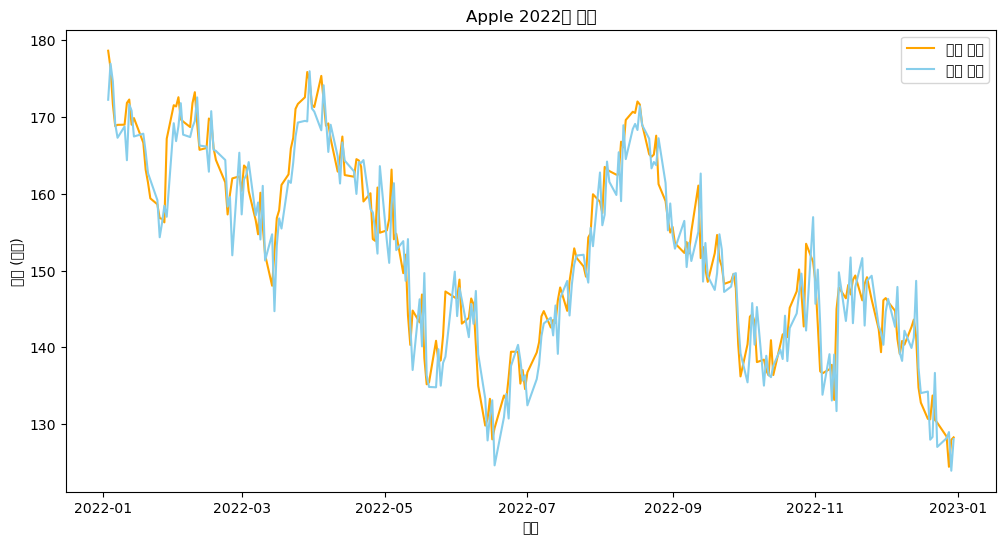

In [27]:
# ✅ 12. 시각화
plt.figure(figsize=(12,6))
plt.title('Apple 2022년 예측')
plt.plot(aapl_dates[split_idx:], y_test, label='실제 종가', color='orange')
plt.plot(aapl_dates[split_idx:], y_pred, label='예측 종가', color='skyblue')
plt.xlabel('날짜')
plt.ylabel('주가 (달러)')
plt.legend()
plt.show()

In [29]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"✅ Test RMSE: {rmse:.2f} 달러")

# R²
r2 = r2_score(y_test, y_pred)
print(f"✅ Test R²: {r2:.4f}")


✅ Test RMSE: 4.02 달러
✅ Test R²: 0.8993


## ✅ 모델링 결과 및 인사이트

- **Baseline 성능**:  
  - MAE ≈ 3.2달러, RMSE ≈ 4.0달러, R² ≈ 0.90
  - Apple 2022년 종가 예측에서 약 2~3% 수준의 오차로 실제 가격을 잘 추적함

- **모델 입력**:  
  - 20일치 OHLCV 시퀀스만 사용  
  - 추가 기술적 지표 없이 순수 가격/거래량 데이터 기반

- **장점**:  
  - 단순한 구조(LSTM 1층)로도 안정적인 예측
  - 타겟 스케일링 없이 원 단위 가격을 바로 예측 → 해석성 우수
  - 후처리 없이 가격 단위 결과를 바로 사용할 수 있어 서비스 적용 용이

- **결론 및 향후 계획**:  
  - 이 결과를 프로젝트의 **baseline**으로 채택
  - 향후 개선 아이디어: 윈도우 크기 조정, 기술적 지표 피처 추가, 다중스텝 예측 확장, 모델 구조 개선(GRU/Transformer)
